In [ ]:
# Устанавливаем необходимые библиотеки
!pip install plotly -q

# Импортируем библиотеки
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime
import plotly.express as px
from google.colab import files
import io

In [ ]:
# Способ 1: Загрузка файла с компьютера
print("Пожалуйста, загрузите файл базы данных")
uploaded = files.upload()

# Если файл загружен, получаем его имя
if uploaded:
    db_filename = list(uploaded.keys())[0]
    print(f"Файл {db_filename} успешно загружен!")
else:
    # Способ 2: Использование демо-данных (если нет реальной БД)
    print("Создаем демо-данные для примера...")
    db_filename = "demo.db"

    # Код для создания демо-базы данных
    import sqlite3
    conn = sqlite3.connect(db_filename)
    cursor = conn.cursor()

    # Создаем таблицы и наполняем демо-данными
    cursor.executescript('''
        CREATE TABLE IF NOT EXISTS places (
            id INTEGER PRIMARY KEY,
            location TEXT
        );

        CREATE TABLE IF NOT EXISTS moves (
            id INTEGER PRIMARY KEY,
            dt DATE,
            place_id INTEGER,
            FOREIGN KEY (place_id) REFERENCES places(id)
        );

        -- Наполняем демо-данными
        INSERT OR IGNORE INTO places (id, location) VALUES
        (1, 'Главный выставочный зал'), (2, 'Галерея современного искусства'),
        (3, 'Музей истории'), (4, 'Центр фотографии'), (5, 'Арт-пространство "Винзавод"'),
        (6, 'Галерея "Red October"'), (7, 'Московский музей'), (8, 'Эрмитаж'),
        (9, 'Третьяковская галерея'), (10, 'Пушкинский музей'),
        (11, 'Галерея на Солянке'), (12, 'Арт-центр "Марс"');

        -- Демо-данные о перемещениях (март-июнь 2024)
        INSERT OR IGNORE INTO moves (dt, place_id) VALUES
        ('2024-03-05', 1), ('2024-03-12', 2), ('2024-03-15', 1), ('2024-03-20', 3),
        ('2024-03-25', 2), ('2024-04-02', 4), ('2024-04-08', 1), ('2024-04-12', 5),
        ('2024-04-18', 3), ('2024-04-22', 6), ('2024-04-29', 2), ('2024-05-05', 7),
        ('2024-05-10', 1), ('2024-05-15', 8), ('2024-05-20', 4), ('2024-05-25', 9),
        ('2024-06-02', 10), ('2024-06-08', 1), ('2024-06-15', 5), ('2024-06-22', 3),
        ('2024-06-28', 2);
    ''')
    conn.commit()
    conn.close()
    print("Демо-база данных создана!")

Пожалуйста, загрузите файл базы данных


Saving museum.db to museum.db
Файл museum.db успешно загружен!


In [ ]:
# Подключаемся к базе данных
import sqlite3
conn = sqlite3.connect(db_filename)

# Получаем данные о перемещениях экспонатов по площадкам с фильтрацией по дате
query = """
    SELECT
        m.dt as move_date,
        p.location as place_name,
        COUNT(m.id) as exhibits_count
    FROM moves m
    JOIN places p ON m.place_id = p.id
    WHERE m.dt IS NOT NULL
    AND m.dt >= '2024-03-01'
    AND m.dt < '2024-07-01'
    GROUP BY m.dt, p.location
    ORDER BY m.dt
"""

df = pd.read_sql(query, conn)
conn.close()

# Показываем первые строки данных
print("📊 ЗАГРУЖЕННЫЕ ДАННЫХ:")
print(f"Количество записей: {len(df)}")
print(f"Период данных: с {df['move_date'].min()} по {df['move_date'].max()}")
print("\nПервые 5 строк данных:")
display(df.head())

📊 ЗАГРУЖЕННЫЕ ДАННЫХ:
Количество записей: 12164
Период данных: с 2024-03-01 00:00:41.000000 по 2024-06-30 23:24:46.000000

Первые 5 строк данных:


,move_date,place_name,exhibits_count
0,2024-03-01 00:00:41.000000,"Нижний Новгород, наб. Кузнецова, д. 3/2 стр. 535",1
1,2024-03-01 00:02:55.000000,"Анапа, ул. Студенческая, д. 36 к. 299",1
2,2024-03-01 00:13:44.000000,"Владивосток, ш. Мая 1, д. 1/4 стр. 7",1
3,2024-03-01 00:26:08.000000,"Анапа, ул. Студенческая, д. 36 к. 299",1
4,2024-03-01 00:31:32.000000,"Обоянь, пер. Вокзальный, д. 320 к. 5/3",1


In [ ]:
# Преобразуем дату в datetime
df['move_date'] = pd.to_datetime(df['move_date'])

# Определяем топ-10 площадок по общему количеству экспонатов за период
top_places = df.groupby('place_name')['exhibits_count'].sum().nlargest(10).index.tolist()

print("🏆 ТОП-10 ПЛОЩАДОК ПО АКТИВНОСТИ:")
for i, place in enumerate(top_places, 1):
    total = df[df['place_name'] == place]['exhibits_count'].sum()
    print(f"{i:2d}. {place:<35} - {total:3d} экспонатов")

# Фильтруем данные только по топ-10 площадкам
df_top = df[df['place_name'].isin(top_places)]

# Группируем по неделям и площадкам
df_top['week_start'] = df_top['move_date'] - pd.to_timedelta(df_top['move_date'].dt.dayofweek, unit='D')
df_top['week_start'] = df_top['week_start'].dt.date

# Создаем сводную таблицу
weekly_data = df_top.pivot_table(
    index='week_start',
    columns='place_name',
    values='exhibits_count',
    aggfunc='sum',
    fill_value=0
)

weekly_data = weekly_data.sort_index()

print(f"\n📈 ДАННЫЕ ДЛЯ АНАЛИЗА:")
print(f"Период анализа: {len(weekly_data)} недель")
print(f"Количество площадок: {len(weekly_data.columns)}")
print(f"Общее количество перемещений: {weekly_data.sum().sum()}")

🏆 ТОП-10 ПЛОЩАДОК ПО АКТИВНОСТИ:
 1. Пермь, бул. К.Маркса, д. 1 стр. 50  - 313 экспонатов
 2. Анапа, ул. Студенческая, д. 36 к. 299 - 308 экспонатов
 3. Владивосток, пер. Азовский, д. 3    - 294 экспонатов
 4. Анапа, бул. Буденного, д. 814 стр. 45 - 293 экспонатов
 5. Уфа, бул. Ясный, д. 51 к. 817       - 292 экспонатов
 6. Курск, ул. Воровского, д. 4/9 к. 8/8 - 285 экспонатов
 7. Пермь, ш. Просторное, д. 48 стр. 146 - 285 экспонатов
 8. Омск, пер. Новгородский, д. 31 стр. 53 - 284 экспонатов
 9. Москва, ш. Театральное, д. 23 стр. 86 - 283 экспонатов
10. Ставрополь, бул. Пограничный, д. 1 стр. 3 - 283 экспонатов

📈 ДАННЫЕ ДЛЯ АНАЛИЗА:
Период анализа: 18 недель
Количество площадок: 10
Общее количество перемещений: 2920


/tmp/ipykernel_13271/1325851445.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top['week_start'] = df_top['move_date'] - pd.to_timedelta(df_top['move_date'].dt.dayofweek, unit='D')
/tmp/ipykernel_13271/1325851445.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top['week_start'] = df_top['week_start'].dt.date


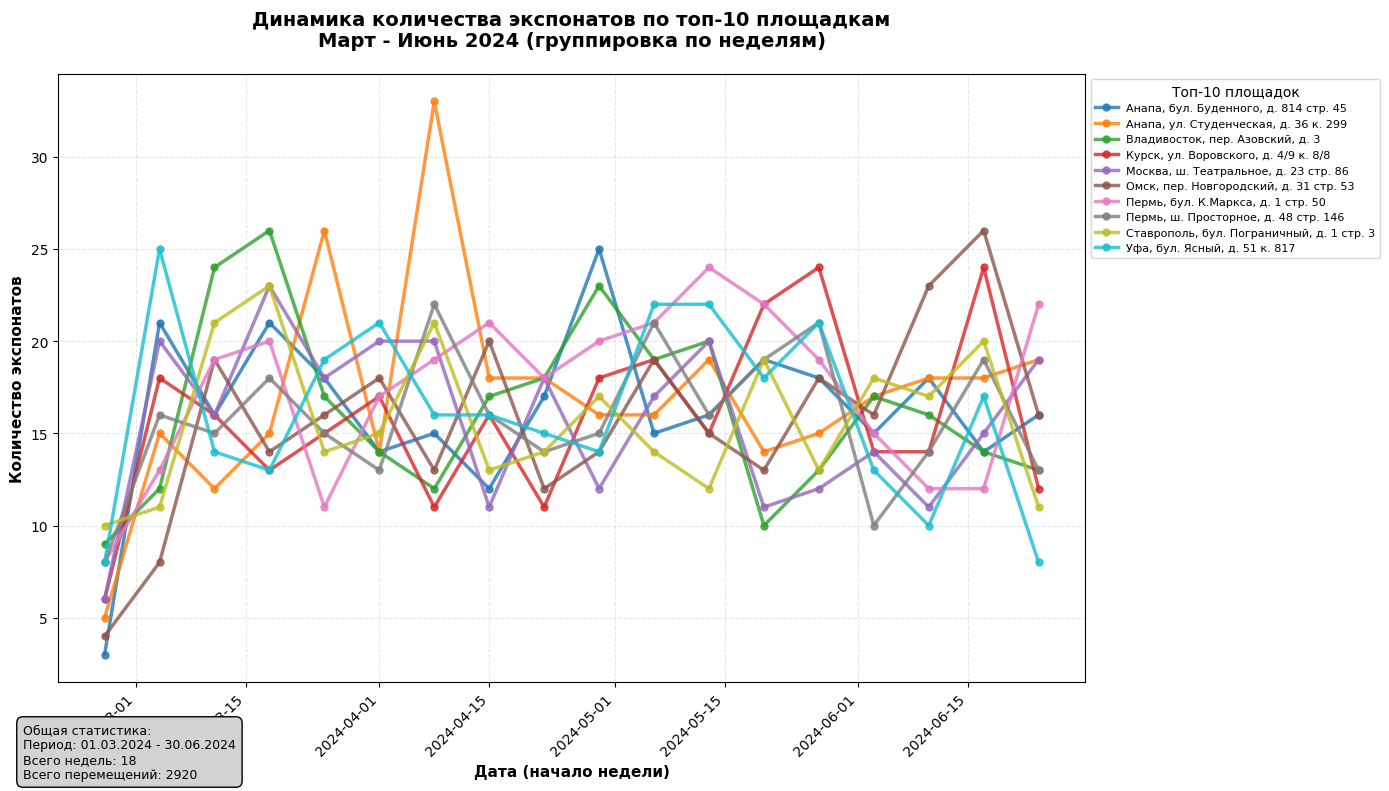

In [ ]:
# Создаем красивый график
plt.figure(figsize=(14, 8))

# Цвета для разных площадок
colors = plt.cm.tab10(np.linspace(0, 1, len(weekly_data.columns)))

# Рисуем линии для каждой площадки
for i, place in enumerate(weekly_data.columns):
    plt.plot(weekly_data.index, weekly_data[place],
             label=place,
             color=colors[i],
             linewidth=2.5,
             marker='o',
             markersize=5,
             alpha=0.8)

# Настраиваем внешний вид
plt.title('Динамика количества экспонатов по топ-10 площадкам\nМарт - Июнь 2024 (группировка по неделям)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Дата (начало недели)', fontsize=11, fontweight='bold')
plt.ylabel('Количество экспонатов', fontsize=11, fontweight='bold')

# Форматируем даты на оси X
plt.xticks(rotation=45, ha='right')

# Добавляем сетку и легенду
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(title='Топ-10 площадок', title_fontsize=10, fontsize=8,
           loc='upper left', bbox_to_anchor=(1, 1))

# Добавляем общую статистику
total_exhibits = weekly_data.sum().sum()
unique_weeks = len(weekly_data)

stats_text = f"""Общая статистика:
Период: 01.03.2024 - 30.06.2024
Всего недель: {unique_weeks}
Всего перемещений: {total_exhibits}"""

plt.figtext(0.02, 0.02, stats_text, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray"))

plt.tight_layout()
plt.show()

In [ ]:
# Подготовка данных для Plotly
plotly_data = df_top.groupby(['week_start', 'place_name'])['exhibits_count'].sum().reset_index()
plotly_data['week_start'] = pd.to_datetime(plotly_data['week_start'])

# Создаем интерактивный график
fig = px.line(plotly_data,
              x='week_start',
              y='exhibits_count',
              color='place_name',
              title='<b>Динамика количества экспонатов по топ-10 площадкам</b><br><sub>Март - Июнь 2024 (группировка по неделям)</sub>',
              labels={'week_start': 'Дата (начало недели)',
                     'exhibits_count': 'Количество экспонатов',
                     'place_name': 'Площадка'},
              line_shape='spline')

# Настраиваем оформление
fig.update_layout(
    title_font_size=16,
    title_x=0.5,
    width=1000,
    height=600,
    xaxis=dict(
        tickangle=45,
        tickformat="%d.%m.%Y"
    ),
    legend=dict(
        title=dict(text='<b>Топ-10 площадок</b>'),
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02
    ),
    hovermode='x unified'
)

# Добавляем маркеры
fig.update_traces(
    mode='lines+markers',
    marker=dict(size=6),
    line=dict(width=3)
)

fig.show()

In [ ]:
# Детальная статистика
print("=" * 80)
print("📋 ДЕТАЛЬНАЯ СТАТИСТИКА ПО ТОП-10 ПЛОЩАДКАМ")
print("=" * 80)
print(f"{'№':<2} {'Площадка':<30} {'Всего':<8} {'Доля':<6} {'Средн/нед':<10} {'Макс/нед':<10}")
print("-" * 80)

for i, place in enumerate(weekly_data.columns, 1):
    total = weekly_data[place].sum()
    percentage = (total / total_exhibits) * 100
    weekly_avg = weekly_data[place].mean()
    weekly_max = weekly_data[place].max()
    print(f"{i:<2} {place:<30} {total:<8} {percentage:>5.1f}% {weekly_avg:>9.1f} {weekly_max:>9}")

print("=" * 80)

# Сводная таблица по неделям
print("\n📅 СВОДНАЯ ТАБЛИЦА ПО НЕДЕЛЯМ:")
weekly_display = weekly_data.copy()
weekly_display['Всего за неделю'] = weekly_display.sum(axis=1)
display(weekly_display.style.background_gradient(cmap='Blues', axis=0))

📋 ДЕТАЛЬНАЯ СТАТИСТИКА ПО ТОП-10 ПЛОЩАДКАМ
№  Площадка                       Всего    Доля   Средн/нед  Макс/нед  
--------------------------------------------------------------------------------
1  Анапа, бул. Буденного, д. 814 стр. 45 293       10.0%      16.3        25
2  Анапа, ул. Студенческая, д. 36 к. 299 308       10.5%      17.1        33
3  Владивосток, пер. Азовский, д. 3 294       10.1%      16.3        26
4  Курск, ул. Воровского, д. 4/9 к. 8/8 285        9.8%      15.8        24
5  Москва, ш. Театральное, д. 23 стр. 86 283        9.7%      15.7        23
6  Омск, пер. Новгородский, д. 31 стр. 53 284        9.7%      15.8        26
7  Пермь, бул. К.Маркса, д. 1 стр. 50 313       10.7%      17.4        24
8  Пермь, ш. Просторное, д. 48 стр. 146 285        9.8%      15.8        22
9  Ставрополь, бул. Пограничный, д. 1 стр. 3 283        9.7%      15.7        23
10 Уфа, бул. Ясный, д. 51 к. 817  292       10.0%      16.2        25

📅 СВОДНАЯ ТАБЛИЦА ПО НЕДЕЛЯМ:


place_name,"Анапа, бул. Буденного, д. 814 стр. 45","Анапа, ул. Студенческая, д. 36 к. 299","Владивосток, пер. Азовский, д. 3","Курск, ул. Воровского, д. 4/9 к. 8/8","Москва, ш. Театральное, д. 23 стр. 86","Омск, пер. Новгородский, д. 31 стр. 53","Пермь, бул. К.Маркса, д. 1 стр. 50","Пермь, ш. Просторное, д. 48 стр. 146","Ставрополь, бул. Пограничный, д. 1 стр. 3","Уфа, бул. Ясный, д. 51 к. 817",Всего за неделю
week_start,,,,,,,,,,,
2024-02-26,3,5,9,6,6,4,8,8,10,8,67
2024-03-04,21,15,12,18,20,8,13,16,11,25,159
2024-03-11,16,12,24,16,16,19,19,15,21,14,172
2024-03-18,21,15,26,13,23,14,20,18,23,13,186
2024-03-25,18,26,17,15,18,16,11,15,14,19,169
2024-04-01,14,14,14,17,20,18,17,13,15,21,163
2024-04-08,15,33,12,11,20,13,19,22,21,16,182
2024-04-15,12,18,17,16,11,20,21,16,13,16,160
2024-04-22,17,18,18,11,18,12,18,14,14,15,155


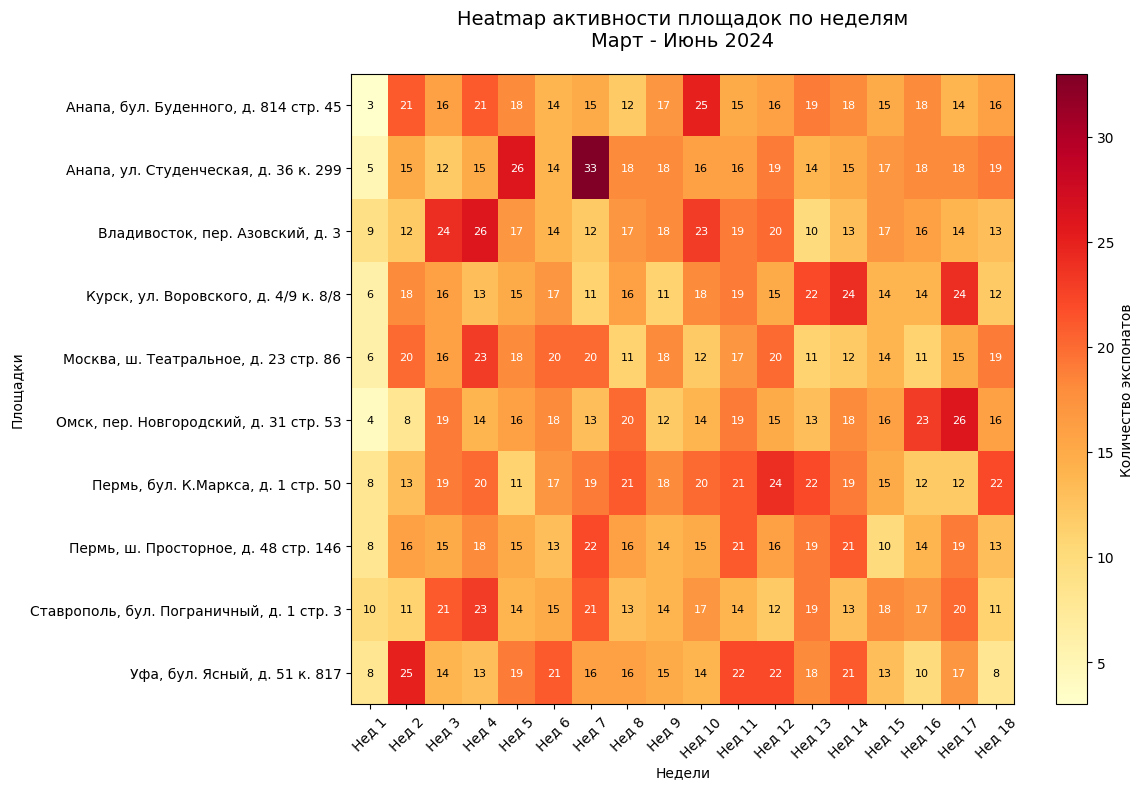

In [ ]:
# Heatmap активности по неделям и площадкам
plt.figure(figsize=(12, 8))

# Транспонируем данные для heatmap
heatmap_data = weekly_data.T

plt.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', interpolation='nearest')
plt.colorbar(label='Количество экспонатов')
plt.title('Heatmap активности площадок по неделям\nМарт - Июнь 2024', fontsize=14, pad=20)
plt.xlabel('Недели')
plt.ylabel('Площадки')

# Подписи для осей
plt.xticks(range(len(weekly_data.index)), [f'Нед {i+1}' for i in range(len(weekly_data.index))], rotation=45)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

# Добавляем значения в ячейки
for i in range(len(heatmap_data.index)):
    for j in range(len(weekly_data.index)):
        plt.text(j, i, f'{heatmap_data.iloc[i, j]}',
                ha='center', va='center', fontsize=8,
                color='white' if heatmap_data.iloc[i, j] > heatmap_data.values.max()/2 else 'black')

plt.tight_layout()
plt.show()

In [ ]:
import sqlite3
import pandas as pd

db_path = 'museum.db'
conn = sqlite3.connect(db_path)

In [ ]:
query_10_1 = """
SELECT *
FROM types
WHERE name LIKE '%изделие%';
"""

df_10_1 = pd.read_sql(query_10_1, conn)
df_10_1

,id,name
0,9,Ювелирное изделие


In [ ]:
query_10_2 = """
SELECT t.name AS type_name,
       COUNT(w.id) AS items_count
FROM types t
LEFT JOIN wings w ON w.type_id = t.id
GROUP BY t.id, t.name
ORDER BY items_count DESC;
"""

df_10_2 = pd.read_sql(query_10_2, conn)
df_10_2

,type_name,items_count
0,Оружие,528
1,Керамика,524
2,Артефакт,520
3,Источник вдохновения,516
4,Монета,505
5,Книга,503
6,Мебель,500
7,Инструмент,498
8,Картина,492
9,Скульптура,486


In [ ]:
query_11 = """
SELECT
    t.name AS type_name,
    SUM(m.price * w.profit * p.scale) AS total_revenue,
    SUM(m.price) AS marketing_cost,
    AVG(w.profit) AS avg_profit,
    ROUND(
        (SUM(m.price * w.profit * p.scale) - SUM(m.price))
        / SUM(m.price) * 100, 2
    ) AS roi_percent
FROM moves m
JOIN wings w ON m.wing_id = w.id
JOIN types t ON w.type_id = t.id
JOIN places p ON m.place_id = p.id
GROUP BY t.id, t.name
ORDER BY roi_percent DESC;
"""

df_11 = pd.read_sql(query_11, conn)
df_11

,type_name,total_revenue,marketing_cost,avg_profit,roi_percent
0,Прибор,7.446268e+08,3.684590e+08,1.634228,102.09
1,Фотография,6.997485e+08,3.504556e+08,1.614984,99.67
2,Инструмент,7.419077e+08,3.724452e+08,1.627752,99.20
3,Монета,7.680265e+08,3.928003e+08,1.582844,95.53
4,Источник вдохновения,7.613432e+08,3.917794e+08,1.581810,94.33
5,Скульптура,6.980353e+08,3.684876e+08,1.540679,89.43
6,Ювелирное изделие,6.970505e+08,3.701825e+08,1.536424,88.30
7,Книга,7.070144e+08,3.762925e+08,1.514998,87.89
8,Рукопись,6.879831e+08,3.664660e+08,1.536785,87.73
9,Картина,6.864120e+08,3.680347e+08,1.518956,86.51
